# Ba8Ga16Ge30：FC2+FC3 拟合与声子谱

Ba8Ga16Ge30 是笼形热电材料。本教程从 **300 K NVE 分子动力学快照**出发，拟合
有效的 FC2+FC3 模型，再用谐波近似画声子谱。这个案例演示 mlfcs 处理大体系的
能力：54 原子原胞、$2\times2\times2$（432 原子）参考超胞、101 帧训练结构。

- 原胞：54 原子，截断 FC2 5.4 Å / FC3 4.35 Å，两个阶的最大体序都是 2；
- 温度是训练数据的属性（快照取自 300 K NVE 轨迹），模型本身是 0 K 谐波量；
- 训练快照与结构来自 hiPhive 的 Ba8Ga16Ge30 笼形热导率示例，重用数据时请
  保留上游案例的归属与许可条款。

运行环境见[教程总览](index.md)。本案例的拟合是教程里内存峰值最高的任务之一，
建议保持串行执行。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from ase.io import iread, read

import mlfcs
from mlfcs import ClusterMap, ClusterSpace, FitSystem
from mlfcs.phonon import Harmonic

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

DATA = Path("data") / "ba8ga16ge30"
TEMPERATURE_K = 300
SUPERCELL_MATRIX = np.diag([2, 2, 2])
CUTOFFS_ANGSTROM = {2: 5.4, 3: 4.35}
MAX_BODY_ORDERS = {2: 2, 3: 2}
SYMPREC_ANGSTROM = 1e-4
SOLVER_RTOL = 1e-8
SOLVER_MAX_STEPS = 10_000
ASR_RTOL = 1e-10
print(f"mlfcs {mlfcs.__version__}")

mlfcs 4.6.0


## 构建模型与拟合系统

`ClusterSpace` 的初始化完成几何验证、spglib 预处理、簇枚举与不变量参数化；
`ForceDataset` 将 101 帧的位移和力收集为数组，`FitSystem` 逐帧构建设计矩阵；不需要保存所有 Atoms
内存。

In [2]:
primitive_atoms = read(DATA / "primitive.vasp")
supercell_atoms = read(DATA / "supercell.vasp")
print(f"primitive: {len(primitive_atoms)} atoms, supercell: {len(supercell_atoms)} atoms")

space = ClusterSpace(
    primitive_atoms,
    cutoffs=CUTOFFS_ANGSTROM,
    max_body_orders=MAX_BODY_ORDERS,
    symprec=SYMPREC_ANGSTROM,
)
mapping = ClusterMap(space, supercell_atoms, supercell_matrix=SUPERCELL_MATRIX)
for block in space.blocks:
    print(f"FC{block.order}: orbits={block.orbits.stop - block.orbits.start}, "
          f"parameters={block.parameters.stop - block.parameters.start}")

primitive: 54 atoms, supercell: 432 atoms
2026-10-07 16:56:24 INFO mlfcs.cluster_space.construction: Cluster-space construction started: primitive_atoms=54 orders=(2, 3) symprec=0.0001


2026-10-07 16:56:24 INFO mlfcs.cluster_space.construction: Primitive symmetry ready: operations=3 symbol=R3


2026-10-07 16:56:24 INFO mlfcs.cluster_space.construction: Order construction started: order=2 cutoff_angstrom=5.4 max_body_order=2


2026-10-07 16:56:24 INFO mlfcs.cluster_space.construction: Candidates ready: order=2 candidates=1188


2026-10-07 16:56:24 INFO mlfcs.cluster_space.construction: Order complete: order=2 orbits=215 parameters=1809 elapsed_s=0.35


...

2026-10-07 16:56:25 INFO mlfcs.cluster_space.construction: Cluster-space construction complete: orders=(2, 3) orbits=597 parameters=8329 elapsed_s=0.74


2026-10-07 16:56:25 INFO mlfcs.mapping.cluster_map: Mapping started: primitive_atoms=54 matrix_source=explicit


2026-10-07 16:56:25 INFO mlfcs.mapping.cluster_map: Supercell validated: supercell_atoms=432 matrix=[[2, 0, 0], [0, 2, 0], [0, 0, 2]]


2026-10-07 16:56:25 INFO mlfcs.mapping.cluster_map: Mapping complete: orbits=597 images=4410 elapsed_s=0.06


FC2: orbits=215, parameters=1809
FC3: orbits=382, parameters=6520


In [3]:
from mlfcs.dataset import ForceDataset
fit_system = FitSystem(ForceDataset(mapping, iread(DATA / "nve.extxyz", index=":")))
print(f"frames={fit_system.n_structures}, equations={fit_system.n_equations}, "
      f"parameters={fit_system.n_parameters}")

2026-10-07 16:56:25 INFO mlfcs.fitting.system: Fit-system construction started: representation=normal supercell_atoms=432 orders=(2, 3) parameters=8329 equations_per_structure=1296


2026-10-07 16:56:25 INFO mlfcs.fitting.design: Force-design compilation started: supercell_atoms=432 orders=(2, 3) parameters=8329


2026-10-07 16:56:25 INFO mlfcs.mapping.cluster_map: Folded rank started: order=all


2026-10-07 16:56:25 INFO mlfcs.mapping.cluster_map: Folded rank complete: parameters=8329 rank=8329 nullity=0 aliases=0 elapsed_s=0.01


2026-10-07 16:56:27 INFO mlfcs.fitting.design: Force-design order ready: order=2 images=1188 basis_bytes=751248


...

2026-10-07 16:58:07 INFO mlfcs.fitting.system: Fit-system accumulation: structures=90 equations=116640 elapsed_s=101.77 structures_per_s=0.884


2026-10-07 16:58:18 INFO mlfcs.fitting.system: Fit-system accumulation: structures=100 equations=129600 elapsed_s=112.90 structures_per_s=0.886


2026-10-07 16:58:22 INFO mlfcs.fitting.system: Fit equations accumulated: representation=normal parameters=8329 structures=101 elapsed_s=116.79


2026-10-07 16:58:23 INFO mlfcs.fitting.system: Fit-system complete: representation=normal structures=101 equations=130896 parameters=8329 shape=(8329, 8329) equation_bytes=555044560 elapsed_s=118.10


frames=101, equations=130896, parameters=8329


## 求解与 ASR 投影

列缩放 MINRES 求解联合法方程；随后 `enforce_asr(rtol=ASR_RTOL)` 把 FC2 与 FC3
分别投影到平移不变性。投影前后的训练误差对比告诉你 ASR 修正了多少物理、
又付出了多少拟合精度。

In [4]:
unconstrained = fit_system.solve(rtol=SOLVER_RTOL, maxiter=SOLVER_MAX_STEPS)
parameters = unconstrained.parameters()
projection = unconstrained.enforce_asr(rtol=ASR_RTOL)
force_constants = projection.force_constants
projected_parameters = force_constants.parameters()

print(f"relative force error before ASR: {fit_system.relative_error(parameters):.6%}")
print(f"relative force error after  ASR: {fit_system.relative_error(projected_parameters):.6%}")
print(f"force RMSE before ASR: {fit_system.rmse(parameters):.6g} eV/Å")
print(f"force RMSE after  ASR: {fit_system.rmse(projected_parameters):.6g} eV/Å")
for report in projection.reports:
    print(
        f"FC{report.order} ASR: relative residual "
        f"{report.relative_before:.3e} -> {report.relative_after:.3e}"
    )

2026-10-07 16:58:23 INFO mlfcs.fitting.system: Fit solve started: representation=normal structures=101 equations=130896 parameters=8329 orders=(2, 3)


2026-10-07 16:58:23 INFO mlfcs.fitting.solve: Solver started: algorithm=MINRES normalization=inverse_column_norm rtol=1e-08 maxiter=10000


2026-10-07 16:58:31 INFO mlfcs.fitting.solve: Solver finished: algorithm=MINRES iterations=346 stop_code=0 physical_normal_residual=8.9225054339e-03


2026-10-07 16:58:31 INFO mlfcs.fitting.system: Fit complete: training_force_rmse=0.0209356790543 eV/angstrom training_relative_force_error=0.049395082 elapsed_s=8.02


2026-10-07 16:58:31 INFO mlfcs.force_constants.asr: ASR projection started: orders=(2, 3) rtol=1e-10


2026-10-07 16:58:31 INFO mlfcs.force_constants.asr: ASR order complete: order=2 equations=486 iterations=17 relative_before=0.00027495 relative_after=3.38877e-15 correction_norm=0.0520842


2026-10-07 16:58:32 INFO mlfcs.force_constants.asr: ASR order complete: order=3 equations=29970 iterations=79 relative_before=0.000790398 relative_after=2.45301e-13 correction_norm=2.20726


2026-10-07 16:58:32 INFO mlfcs.force_constants.asr: ASR projection complete: orders=(2, 3) elapsed_s=0.40


relative force error before ASR: 4.939508%
relative force error after  ASR: 5.295640%
force RMSE before ASR: 0.0209357 eV/Å
force RMSE after  ASR: 0.0224451 eV/Å
FC2 ASR: relative residual 2.750e-04 -> 3.389e-15
FC3 ASR: relative residual 7.904e-04 -> 2.453e-13


## 谐波声子谱

`Harmonic.run_band_path(npoints=200)` 根据原胞晶胞生成 ASE 默认高对称路径，
返回频率、距离、标签和分段区间。54 原子原胞有 162 支声子；每个 q 点按频率排序，
不做跨点模式连接。自动路径依据晶胞几何，不分析原子排列。

In [5]:
harmonic = Harmonic(force_constants)
bands = harmonic.run_band_path(npoints=200)
print(f"path: {bands.path}")
print(f"bands: {bands.frequencies_thz.shape[1]}, qpoints: {len(bands.qpoints)}")

2026-10-07 16:58:32 INFO mlfcs.phonon.harmonic: Harmonic preparation started: primitive_atoms=54


2026-10-07 16:58:32 INFO mlfcs.phonon.harmonic: Harmonic preparation complete: terms=1188 elapsed_s=0.03


2026-10-07 16:58:32 INFO mlfcs.phonon.harmonic: Harmonic frequencies: qpoints=200 modes_per_q=162 imaginary_modes=4 range=[-1.0422157e-07, 7.7235585] THz elapsed=0.45 s


path: GLB1,BZGX,QFP1Z,LP
bands: 162, qpoints: 200


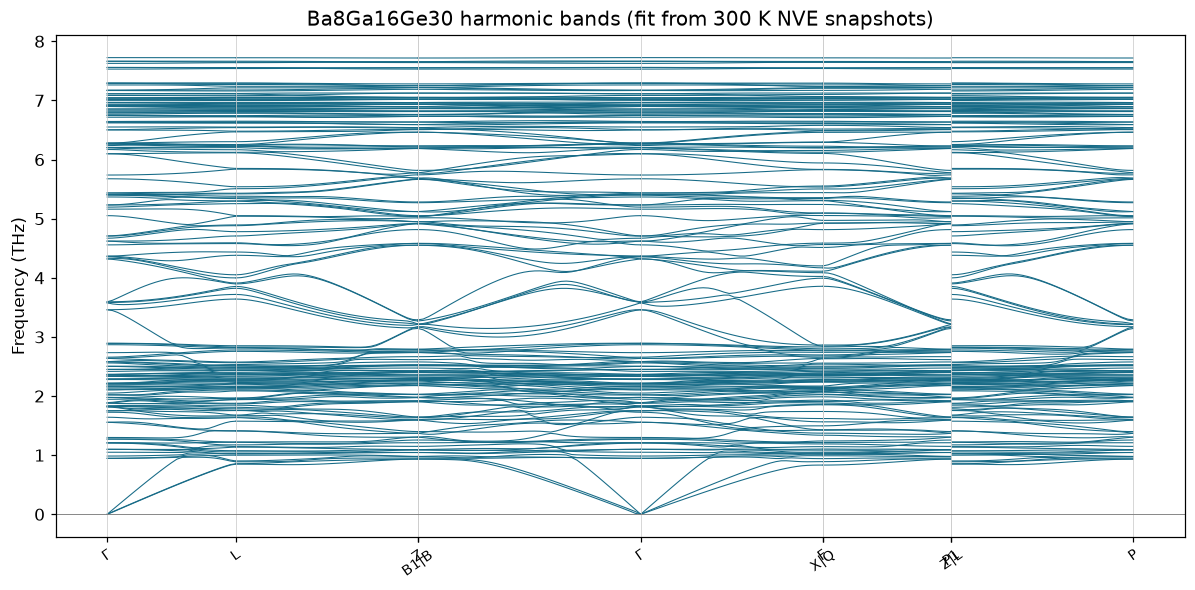

In [6]:
fig, axis = plt.subplots(figsize=(11, 5.5))
for segment in bands.segments:
    axis.plot(bands.distances[segment], bands.frequencies_thz[segment], color="#176b87", lw=0.7)
for position in bands.tick_positions:
    axis.axvline(position, color="0.8", lw=0.5)
axis.axhline(0.0, color="0.5", lw=0.6)
axis.set_xticks(bands.tick_positions, bands.tick_labels)
axis.tick_params(axis="x", labelrotation=35, labelsize=9)
axis.set_ylabel("Frequency (THz)")
axis.set_title(f"Ba8Ga16Ge30 harmonic bands (fit from {TEMPERATURE_K} K NVE snapshots)")
fig.tight_layout()
plt.show()

## 小结

- 大体系（54 原子原胞、432 原子超胞、8000+ 参数）的拟合在笔记本内存下完全
  可行，前提是逐案例串行执行；
- `ForceDataset` 收集位移和力；`FitSystem` 逐帧累加方程，`n_structures/n_equations/n_parameters` 随时
  可查；
- 谐波声子谱是检验 FC2 质量的第一工具：笼形材料的平移模、光学支劈裂与
  低频"摇铃模"都应与文献定性一致。
- 导出（phonopy/shengbte 文本或 HDF5）与热导率验证工作流见
  [Si：FC2–FC5 联合拟合与热导率](si-fitting.ipynb)与
  [K4As4Pt2](k4as4pt2.ipynb) 教程。